## 7. Другий прогін

### Підготовка до v2

Які зміни були застосовано відносно першого прогону:
- класи `people` та `pedestrian` злиті в один `person` скриптом `scripts/merge_person_classes.py`;
- `imgsz` з 640 на *800*, адже дрібні bbox займають більше пікселів;
- *100 епох*, `batch=4` та `patience=25`.

Відпрацювали всі 100 епох, близько 6.3 год. mAP ще підростав ближче до кінця, early stopping не зупинив.

Заранено командою через CLI:
```bash
yolo detect train data=data/visdrone_merged.yaml model=yolov8n.pt epochs=100 imgsz=800 batch=4 patience=25 device=0 workers=2 project=runs_v2/detect_v2 name=visdrone_yolov8n_v2
```

### Вийшло на v2

Найкращі ваги: `runs_v2/detect_v2/visdrone_yolov8n_v2/weights/best.pt`

**val** показав: mAP50 *0.39*, precision *0.52*, recall *0.40*
**test** показав: mAP50 *0.33*, precision *0.45*, recall *0.36*

Поруч з v1: val був 0.30 / 0.43 / 0.33, test 0.26 / 0.39 / 0.29
тобто приріст присутній і на val, і на test, не лише підгон під валідації

По класах на val: **car** 0.79 [було 0.73], **person** 0.47 [замість плутанини people/pedestrian], **bicycle** 0.11 [було 0.06]. **awning-tricycle** 0.14.

### Графіки train

**v1** (`results.png`):

![results_v1](../photo/results.png)

**v2** (`results_v2.png`):

![results_v2](../photo/results_v2.png)

### Порівняння динаміки метрик (v1 vs v2)

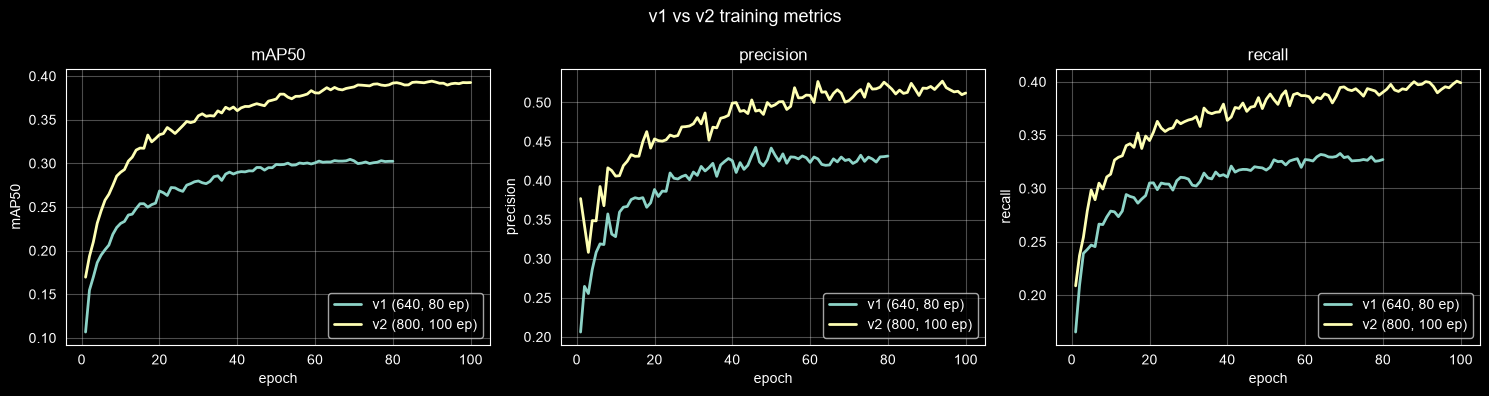

v1 tail:


,epoch,metrics/mAP50(B),metrics/precision(B),metrics/recall(B)
77,78,0.30209,0.43036,0.32544
78,79,0.30235,0.43071,0.32596
79,80,0.30238,0.43144,0.32709


v2 tail:


,epoch,metrics/mAP50(B),metrics/precision(B),metrics/recall(B)
97,98,0.39260,0.51435,0.39782
98,99,0.39245,0.51003,0.40058
99,100,0.39262,0.51212,0.39905


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent

v1_csv = ROOT / "runs/detect/runs/detect/visdrone_yolov8n/results.csv"
v2_csv = ROOT / "runs/detect/runs_v2/detect_v2/visdrone_yolov8n_v2/results.csv"

for p in (v1_csv, v2_csv):
    if not p.exists():
        raise FileNotFoundError(f"Not found: {p}")

df1 = pd.read_csv(v1_csv)
df2 = pd.read_csv(v2_csv)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ("metrics/mAP50(B)", "mAP50"),
    ("metrics/precision(B)", "precision"),
    ("metrics/recall(B)", "recall"),
]

for ax, (col, title) in zip(axes, metrics):
    ax.plot(df1["epoch"], df1[col], label="v1 (640, 80 ep)", linewidth=2)
    ax.plot(df2["epoch"], df2[col], label="v2 (800, 100 ep)", linewidth=2)
    ax.set_xlabel("epoch")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("v1 vs v2 training metrics", fontsize=13)
plt.tight_layout()
plt.show()

print("v1 tail:")
display(df1[["epoch", "metrics/mAP50(B)", "metrics/precision(B)", "metrics/recall(B)"]].tail(3))
print("v2 tail:")
display(df2[["epoch", "metrics/mAP50(B)", "metrics/precision(B)", "metrics/recall(B)"]].tail(3))

### Confusion matrix v2

![cm_v2](../photo/confusion_matrix_v2.png)

Проблема з `people`/`pedestrian` зникла як окрема пара в один клас `person`. Слабкі місця лишаються на дрібних або рідкісних класах, це видно і по низькому mAP у `bicycle`.

### Висновок

v2 кращий за перший прогін: +0.09 mAP50 на val, +0.07 на test при тій самій YOLOv8n.